#**Scenario 4**
---
##**TL-MobileNetV2 - Optimizer SGD - Learning Rate 0.0001 - Center Cropping Dataset**

###**Import Dataset**

In [ ]:
#--- Mount Google Drive ---
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#--- Import Dataset Ori ---
dataset_path = '/content/drive/MyDrive/SKRIPSI/dataset/dataset/final_dataset_crop' # lokasi dataset

import os
if os.path.exists(dataset_path):
    print("Dataset ditemukan di:", dataset_path)
else:
    print("Folder dataset tidak ditemukan, cek kembali path-nya.")

Dataset ditemukan di: /content/drive/MyDrive/SKRIPSI/dataset/dataset/final_dataset_crop


In [ ]:
#--- Cek Jumlah Data Per Kelas ---
import os

dataset_path = '/content/drive/MyDrive/SKRIPSI/dataset/dataset/final_dataset_crop'  # lokasi dataset

total_files = 0

print("Jumlah data per kelas:\n")

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        files = [
            f for f in os.listdir(class_path)
            if f.lower().endswith('.jpg')
        ]
        num_files = len(files)
        total_files += num_files

        print(f"{class_name}: {num_files} data")

print("\nTotal seluruh data:", total_files)

Jumlah data per kelas:

pisang susu: 400 data
pisang mas: 400 data
pisang barlin: 400 data
pisang embug: 400 data
pisang cavendish: 400 data
pisang candi: 400 data
pisang ambon: 400 data
pisang agung: 400 data

Total seluruh data: 3200


In [ ]:
#--- Display Dataset ---
import os
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = '/content/drive/MyDrive/SKRIPSI/dataset/dataset/final_dataset_crop' # lokasi dataset

# Ambil daftar kelas (subfolder)
classes = sorted([
    d for d in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, d))
])

# Setup figure: 2 baris x 4 kolom
plt.figure(figsize=(16, 8))

for i, class_name in enumerate(classes):
    class_path = os.path.join(dataset_path, class_name)

    # Ambil satu gambar pertama dari kelas tersebut
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith('.jpg')
    ]

    if len(images) == 0:
        continue

    img_path = os.path.join(class_path, images[0])
    img = Image.open(img_path)

    # Plot
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

###**Split Dataset 80:20 (train:val)**

In [ ]:
#--- Split Dataset 80:20 (train:val) ---
import os
import shutil
import random

# Path dataset asli
dataset_path = '/content/drive/MyDrive/SKRIPSI/dataset/dataset/final_dataset_crop' # lokasi dataset

# Path output split
output_path = '/content/drive/MyDrive/SKRIPSI/dataset/final_dataset/final_dataset_crop' # lokasi dataset yang sudah di split
train_path = os.path.join(output_path, 'train')
val_path = os.path.join(output_path, 'val')

# membuat folder train & val jika belum ada
os.makedirs(train_path, exist_ok=True)
os.makedirs(val_path, exist_ok=True)

# Seed agar hasil split konsisten
random.seed(42)

# Loop setiap kelas
for class_name in os.listdir(dataset_path):
    class_dir = os.path.join(dataset_path, class_name)

    if not os.path.isdir(class_dir):
        continue

    # Ambil semua file gambar
    images = [
        f for f in os.listdir(class_dir)
        if f.lower().endswith('.jpg')
    ]

    random.shuffle(images)

    # Hitung jumlah train (80%)
    split_idx = int(0.8 * len(images))
    train_images = images[:split_idx]
    val_images = images[split_idx:]

    # Buat folder kelas
    os.makedirs(os.path.join(train_path, class_name), exist_ok=True)
    os.makedirs(os.path.join(val_path, class_name), exist_ok=True)

    # Copy file ke folder train
    for img in train_images:
        shutil.copy(
            os.path.join(class_dir, img),
            os.path.join(train_path, class_name, img)
        )

    # Copy file ke folder val
    for img in val_images:
        shutil.copy(
            os.path.join(class_dir, img),
            os.path.join(val_path, class_name, img)
        )

    print(f"{class_name}: {len(train_images)} train | {len(val_images)} val")

print("\nSplit dataset selesai (80% train, 20% val)")

pisang susu: 320 train | 80 val
pisang mas: 320 train | 80 val
pisang barlin: 320 train | 80 val
pisang embug: 320 train | 80 val
pisang cavendish: 320 train | 80 val
pisang candi: 320 train | 80 val
pisang ambon: 320 train | 80 val
pisang agung: 320 train | 80 val

Split dataset selesai (80% train, 20% val)


In [ ]:
#--- Cek Jumlah Dataset ---
import os

dataset_split_path = '/content/drive/MyDrive/SKRIPSI/dataset/final_dataset/final_dataset_crop'
train_path = os.path.join(dataset_split_path, 'train')
val_path  = os.path.join(dataset_split_path, 'val')

def count_images_per_class(path):
    class_counts = {}
    for class_name in sorted(os.listdir(path)):
        class_dir = os.path.join(path, class_name)
        if os.path.isdir(class_dir):
            images = [
                f for f in os.listdir(class_dir)
                if f.lower().endswith('.jpg')
            ]
            class_counts[class_name] = len(images)
    return class_counts

# Hitung jumlah data
train_counts = count_images_per_class(train_path)
val_counts  = count_images_per_class(val_path)

# Tampilkan hasil
print("📊 Jumlah data TRAIN per kelas:")
for cls, count in train_counts.items():
    print(f"{cls}: {count}")

print("\n📊 Jumlah data VAL per kelas:")
for cls, count in val_counts.items():
    print(f"{cls}: {count}")

print("\nTotal TRAIN:", sum(train_counts.values()))
print("Total VAL :", sum(val_counts.values()))

📊 Jumlah data TRAIN per kelas:
pisang agung: 320
pisang ambon: 320
pisang barlin: 320
pisang candi: 320
pisang cavendish: 320
pisang embug: 320
pisang mas: 320
pisang susu: 320

📊 Jumlah data VAL per kelas:
pisang agung: 80
pisang ambon: 80
pisang barlin: 80
pisang candi: 80
pisang cavendish: 80
pisang embug: 80
pisang mas: 80
pisang susu: 80

Total TRAIN: 2560
Total VAL : 640


###**Import Dataset Split**

In [ ]:
#-- Import Dataset Split --
dataset_path = '/content/drive/MyDrive/SKRIPSI/dataset/final_dataset/final_dataset_crop' # lokasi dataset

import os
if os.path.exists(dataset_path):
    print("Dataset ditemukan di:", dataset_path)
else:
    print("Folder dataset tidak ditemukan, cek kembali path-nya.")

Dataset ditemukan di: /content/drive/MyDrive/SKRIPSI/dataset/final_dataset/final_dataset_crop


In [ ]:
#--- Cek Jumlah Dataset ---
import os

dataset_split_path = '/content/drive/MyDrive/SKRIPSI/dataset/final_dataset/final_dataset_crop'
train_path = os.path.join(dataset_split_path, 'train')
val_path  = os.path.join(dataset_split_path, 'val')

def count_images_per_class(path):
    class_counts = {}
    for class_name in sorted(os.listdir(path)):
        class_dir = os.path.join(path, class_name)
        if os.path.isdir(class_dir):
            images = [
                f for f in os.listdir(class_dir)
                if f.lower().endswith('.jpg')
            ]
            class_counts[class_name] = len(images)
    return class_counts

# Hitung jumlah data
train_counts = count_images_per_class(train_path)
val_counts  = count_images_per_class(val_path)

# Tampilkan hasil
print("📊 Jumlah data TRAIN per kelas:")
for cls, count in train_counts.items():
    print(f"{cls}: {count}")

print("\n📊 Jumlah data VAL per kelas:")
for cls, count in val_counts.items():
    print(f"{cls}: {count}")

print("\nTotal TRAIN:", sum(train_counts.values()))
print("Total VAL :", sum(val_counts.values()))

📊 Jumlah data TRAIN per kelas:
pisang agung: 320
pisang ambon: 320
pisang barlin: 320
pisang candi: 320
pisang cavendish: 320
pisang embug: 320
pisang mas: 320
pisang susu: 320

📊 Jumlah data VAL per kelas:
pisang agung: 80
pisang ambon: 80
pisang barlin: 80
pisang candi: 80
pisang cavendish: 80
pisang embug: 80
pisang mas: 80
pisang susu: 80

Total TRAIN: 2560
Total VAL : 640


###**Preprocessing Dataset**

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, AveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [ ]:
train_dir = '/content/drive/MyDrive/SKRIPSI/dataset/final_dataset/final_dataset_crop/train'
val_dir = '/content/drive/MyDrive/SKRIPSI/dataset/final_dataset/final_dataset_crop/val'

In [ ]:
#--- Preprocessing Dataset ---
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input # Normalisasi [-1, 1]
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2560 images belonging to 8 classes.
Found 640 images belonging to 8 classes.


###**Pemodelan Arsitektur MobileNetV2**

In [ ]:
#--- Load MobileNetV2 (Pretrained ImageNet) ---
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze semua layer base model
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#-- Penambahan Head Custom Layer --

# Tambahkan custom classifier di akhir
x = base_model.output
x = AveragePooling2D(pool_size=(7, 7))(x)
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(8, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

###**Compile dengan Optimizer SGD dan Learning Rate 0.0001**

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(
        learning_rate=0.0001,
        momentum=0.9 # Momentum yang umum digunakan
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,587,976 (9.87 MB)

 Trainable params: 329,992 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

###**Training Model**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

#--- Early Stopping untuk mencegah overfitting ---
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    min_delta=0.001,
    patience=10,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

#--- Model Check Point untuk menyimpan model terbaik ---
checkpoint = ModelCheckpoint(
    'best_model_mobilenetv2.h5',
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

In [ ]:
#--- Training model ---
history = model.fit(
    train_generator,
    epochs=100,
    validation_data=val_generator,
    callbacks=[early_stopping]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1000s 12s/step - accuracy: 0.1556 - loss: 2.3052 - val_accuracy: 0.4891 - val_loss: 1.6738
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 382s 5s/step - accuracy: 0.3113 - loss: 1.8227 - val_accuracy: 0.7078 - val_loss: 1.3473
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 375s 5s/step - accuracy: 0.4632 - loss: 1.4699 - val_accuracy: 0.8031 - val_loss: 1.1301
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 374s 5s/step - accuracy: 0.5670 - loss: 1.2671 - val_accuracy: 0.8453 - val_loss: 0.9751
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 384s 5s/step - accuracy: 0.6249 - loss: 1.1405 - val_accuracy: 0.8797 - val_loss: 0.8583
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 384s 5s/step - accuracy: 0.6718 - loss: 1.0305 - val_accuracy: 0.9047 - val_loss: 0.7669
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 375s 5s/step - accuracy: 0.7269 - loss: 0.9183 - val_accuracy: 0.9187 - val_loss: 0.6921
Epoch 8/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 377s 5s/step - accuracy: 0.7519 - loss: 0.8584 - val_accuracy: 

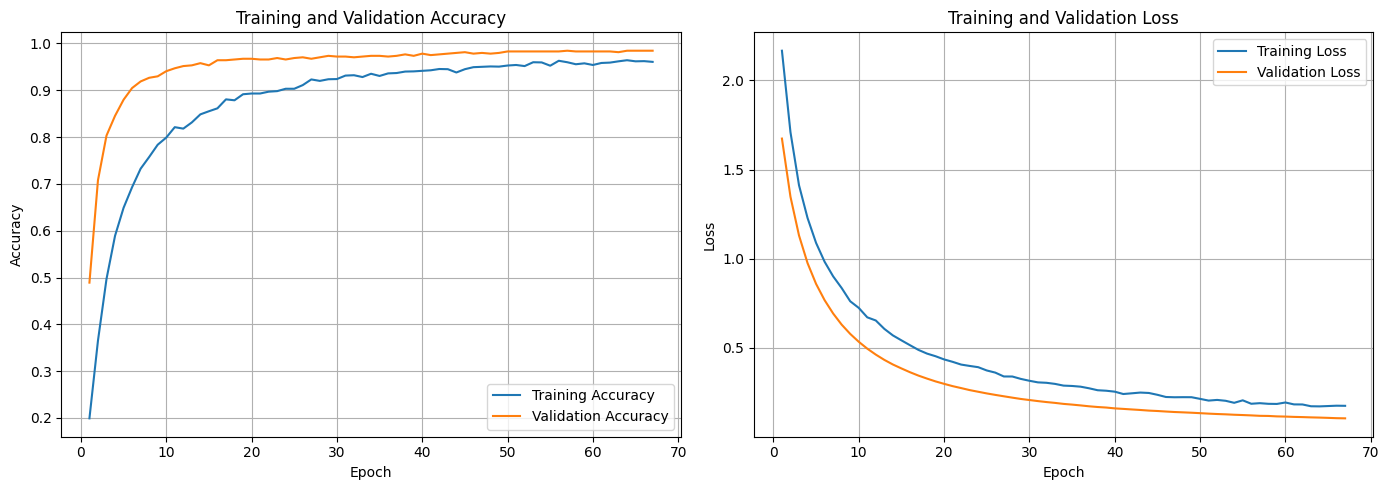

In [ ]:
#--- Menampilkan Grafik Akurasi dan Loss ---
import matplotlib.pyplot as plt

# Ambil data dari history
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(accuracy) + 1)

plt.figure(figsize=(14, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, accuracy, label='Training Accuracy')
plt.plot(epochs_range, val_accuracy, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

###**Confussion Matrix**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# Prediksi kelas
y_pred_prob = model.predict(val_generator)
y_pred = np.argmax(y_pred_prob, axis=1)

# Label sebenarnya
y_true = val_generator.classes

# Nama kelas
class_names = list(val_generator.class_indices.keys())

20/20 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step


In [ ]:
cm = confusion_matrix(y_true, y_pred)

<Figure size 800x800 with 0 Axes>

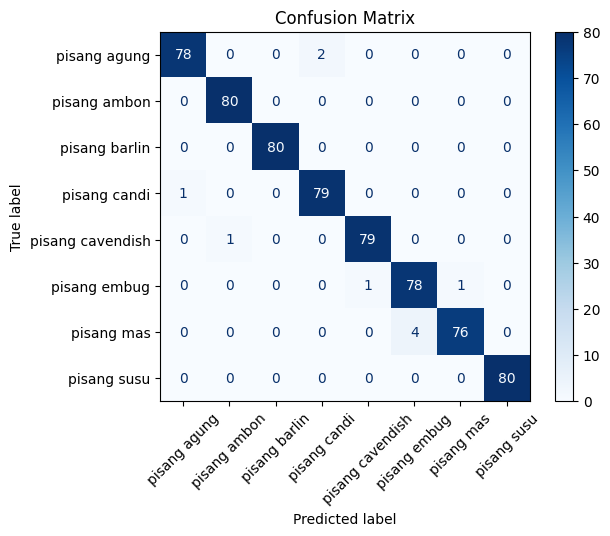

In [ ]:
plt.figure(figsize=(8, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix')
plt.show()

###**Precision, Recall, dan F1-Score**

In [ ]:
from sklearn.metrics import classification_report

# Tampilkan classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print("Classification Report:\n")
print(report)

Classification Report:

                  precision    recall  f1-score   support

    pisang agung     0.9873    0.9750    0.9811        80
    pisang ambon     0.9877    1.0000    0.9938        80
   pisang barlin     1.0000    1.0000    1.0000        80
    pisang candi     0.9753    0.9875    0.9814        80
pisang cavendish     0.9875    0.9875    0.9875        80
    pisang embug     0.9512    0.9750    0.9630        80
      pisang mas     0.9870    0.9500    0.9682        80
     pisang susu     1.0000    1.0000    1.0000        80

        accuracy                         0.9844       640
       macro avg     0.9845    0.9844    0.9844       640
    weighted avg     0.9845    0.9844    0.9844       640

